У цьому ДЗ ми потренуємось розв'язувати задачу багатокласової класифікації за допомогою логістичної регресії з використанням стратегій One-vs-Rest та One-vs-One, оцінити якість моделей та порівняти стратегії.

### Опис задачі і даних

**Контекст**

В цьому ДЗ ми працюємо з даними про сегментацію клієнтів.

Сегментація клієнтів – це практика поділу бази клієнтів на групи індивідів, які схожі між собою за певними критеріями, що мають значення для маркетингу, такими як вік, стать, інтереси та звички у витратах.

Компанії, які використовують сегментацію клієнтів, виходять з того, що кожен клієнт є унікальним і що їхні маркетингові зусилля будуть більш ефективними, якщо вони орієнтуватимуться на конкретні, менші групи зі зверненнями, які ці споживачі вважатимуть доречними та які спонукатимуть їх до купівлі. Компанії також сподіваються отримати глибше розуміння уподобань та потреб своїх клієнтів з метою виявлення того, що кожен сегмент цінує найбільше, щоб точніше адаптувати маркетингові матеріали до цього сегменту.

**Зміст**.

Автомобільна компанія планує вийти на нові ринки зі своїми існуючими продуктами (P1, P2, P3, P4 і P5). Після інтенсивного маркетингового дослідження вони дійшли висновку, що поведінка нового ринку схожа на їхній існуючий ринок.

На своєму існуючому ринку команда з продажу класифікувала всіх клієнтів на 4 сегменти (A, B, C, D). Потім вони здійснювали сегментовані звернення та комунікацію з різними сегментами клієнтів. Ця стратегія працювала для них надзвичайно добре. Вони планують використати ту саму стратегію на нових ринках і визначили 2627 нових потенційних клієнтів.

Ви маєте допомогти менеджеру передбачити правильну групу для нових клієнтів.

В цьому ДЗ використовуємо дані `customer_segmentation_train.csv`[скачати дані](https://drive.google.com/file/d/1VU1y2EwaHkVfr5RZ1U4MPWjeflAusK3w/view?usp=sharing). Це `train.csv`з цього [змагання](https://www.kaggle.com/datasets/abisheksudarshan/customer-segmentation/data?select=train.csv)

**Завдання 1.** Завантажте та підготуйте датасет до аналізу. Виконайте обробку пропущених значень та необхідне кодування категоріальних ознак. Розбийте на тренувальну і тестувальну вибірку, де в тесті 20%. Памʼятаємо, що весь препроцесинг ліпше все ж тренувати на тренувальній вибірці і на тестувальній лише використовувати вже натреновані трансформери.
Але в даному випадку оскільки значень в категоріях небагато, можна зробити обробку і на оригінальних даних, а потім розбити - це простіше. Можна також реалізувати процесинг і тренування моделі з пайплайнами. Обирайте як вам зручніше.

In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
raw_df = pd.read_csv('customer_segmentation_train.csv')

In [4]:
raw_df.info()  # Перевіряю інформацію про змінні в датасеті

<class 'pandas.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   str    
 2   Ever_Married     7928 non-null   str    
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   str    
 5   Profession       7944 non-null   str    
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   str    
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   str    
 10  Segmentation     8068 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 918.9 KB


In [5]:
raw_df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [6]:
# Створюємо трен. і вал. набори
train_df, val_df = train_test_split(raw_df, test_size=0.20, random_state=42, stratify=raw_df["Segmentation"])

In [7]:
#
input_cols = list(train_df.columns)[1:-1] # прибрав колонку з ID та колонку з таргетом
target_col = 'Segmentation' # цільова мультикласова
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df[target_col].copy()

In [8]:
# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

C:\Users\yevhe\AppData\Local\Temp\ipykernel_30544\1073162301.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_inputs.select_dtypes('object').columns.tolist()


In [9]:
train_df[numeric_cols].head() 

,Age,Work_Experience,Family_Size
917,32,9.0,1.0
3398,72,NaN,2.0
2045,33,1.0,4.0
8060,48,0.0,6.0
4604,28,9.0,1.0


In [10]:
raw_df.isna().sum() #Перевіряю на пропущені значення

ID                   0
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
Segmentation         0
dtype: int64

**Як бачимо, у нас є пропущені значення навіть для категоріальних даних, що потрібно врахувати в нашому пайплайні далі**

In [11]:
# Створюємо трансформери для числових і категоріальних колонок, але для оригінальної моделі
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # заповнюю пропущені значення медіаною
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Треба також заповнити порожні значення для категоріальних змінних
    ('onehot', OneHotEncoder(handle_unknown="ignore")) # Прочитав, що це потрібно на випадок, якщо випадково у валідаційному наборі не було однієї з категорій.
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн для моделі на оригінальних даних
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', OneVsRestClassifier(LogisticRegression(solver='liblinear', max_iter=1000))) #додав One-vs-Rest класифікатор
])


In [13]:
model_pipeline.fit(train_inputs, train_targets) # Вже до 3го завдання зрозумів, що мені незручно буде робити через пайплайн, але вирішив в завданні 1 погратися все таки.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

F1 (macro): 0.4800772633520691


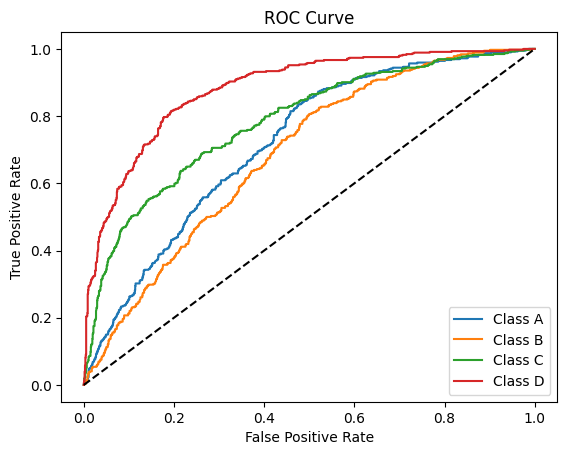

In [16]:
# Тестування для оригінальних даних
from sklearn.metrics import f1_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

preds = model_pipeline.predict(val_inputs)
probs = model_pipeline.predict_proba(val_inputs)

# F1-score
print("F1 (macro):", f1_score(val_targets, preds, average='macro'))

# ROC curve
classes = model_pipeline.classes_
y_bin = label_binarize(val_targets, classes=classes)

plt.figure()

for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, label=f'Class {c}')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**ОБРОБКА ДАНИХ ДЛЯ РЕСЕМПЛИНГУ**

In [22]:
# Створив копію, щоб не змінювати оригінальні дані
X_train_resample = train_inputs.copy()
y_train_resample = train_targets.copy()

In [23]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

In [24]:
X_train_resample[numeric_cols] = num_imputer.fit_transform(X_train_resample[numeric_cols])
X_train_resample[categorical_cols] = cat_imputer.fit_transform(X_train_resample[categorical_cols])
X_train_resample[categorical_cols] = ordinal_encoder.fit_transform(X_train_resample[categorical_cols])

In [37]:
# На завданні 3 зрозумів, що не застосував натреновані трансформери на валідаційних даних, бо почало викидати помилку про пропущені значення в валідаційних даних.
X_val_resample = val_inputs.copy() # теж створив копію валідаційних даних

X_val_resample[numeric_cols] = num_imputer.transform(X_val_resample[numeric_cols])
X_val_resample[categorical_cols] = cat_imputer.transform(X_val_resample[categorical_cols])
X_val_resample[categorical_cols] = ordinal_encoder.transform(X_val_resample[categorical_cols])

***ВИСНОВКИ ДО ЗАВДАННЯ 1: Зрозумів, що поспішив в завданні 1 робити те, що треба робити в завданні 2. І паплайн все дуже ускладнив мені. Препроцесинг виявилося простіше зробити без пайплайну. Тому потім зробив окрему обробку для ресеплингу. Також в процесі роботи виявив, що здається не варто робити скейлінг, якщо будеш робити рісемплінг, а в датасеті поєднання числових та категоріальних колонок. Тому в обробці даних для SMOTE і SMOTE-Tomek не робив масштабування числових даних. В в тестуванні мого пайплайну вже побачив, що найкраще передбачається клас Д, а найгірше В. Очевидно, що треба покращувати можливість передбачати клас В.***

**Завдання 2. Важливо уважно прочитати все формулювання цього завдання до кінця!**

Застосуйте методи ресемплингу даних SMOTE та SMOTE-Tomek з бібліотеки imbalanced-learn до тренувальної вибірки. В результаті у Вас має вийти 2 тренувальних набори: з апсемплингом зі SMOTE, та з ресамплингом з SMOTE-Tomek.

Увага! В нашому наборі даних є як категоріальні дані, так і звичайні числові. Базовий SMOTE не буде правильно працювати з категоріальними даними, але є його модифікація, яка буде. Тому в цього завдання є 2 виконання

  1. Застосувати SMOTE базовий лише на НЕкатегоріальних ознаках.

  2. Переглянути інформацію про метод [SMOTENC](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTENC.html#imblearn.over_sampling.SMOTENC) і використати цей метод в цій задачі. За цей спосіб буде +3 бали за це завдання і він рекомендований для виконання.

  **Підказка**: аби скористатись SMOTENC треба створити змінну, яка містить індекси ознак, які є категоріальними (їх номер серед колонок) і передати при ініціації екземпляра класу `SMOTENC(..., categorical_features=cat_feature_indeces)`.
  
  Ви також можете розглянути варіант використання варіації SMOTE, який працює ЛИШЕ з категоріальними ознаками [SMOTEN](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTEN.html)

In [25]:
from imblearn.over_sampling import SMOTENC
from imblearn.combine import SMOTETomek

In [32]:
# створення змінної, яка містить індекси ознак, які є категоріальними (їх номер серед колонок), бо алгоритм SMOTENC має знати, які змінні категоріальні, щоб по іншому їх обробити
cat_feature_indices = [X_train_resample.columns.get_loc(col) for col in categorical_cols]

In [27]:
# SMOTENC 
smotenc = SMOTENC(categorical_features=cat_feature_indices, random_state=42)
X_train_smote, y_train_smote = smotenc.fit_resample(X_train_resample, y_train_resample)

In [28]:
# SMOTE - Tomek
smote_tomek = SMOTETomek(
    smote=SMOTENC(categorical_features=cat_feature_indices, random_state=42),
    random_state=42
)
X_train_smotetomek, y_train_smotetomek = smote_tomek.fit_resample(X_train_resample, y_train_resample)

In [29]:
print("Original:", y_train_resample.value_counts())
print("SMOTE:", y_train_smote.value_counts())
print("SMOTE-Tomek:", y_train_smotetomek.value_counts())

Original: Segmentation
D    1814
A    1578
C    1576
B    1486
Name: count, dtype: int64
SMOTE: Segmentation
A    1814
B    1814
C    1814
D    1814
Name: count, dtype: int64
SMOTE-Tomek: Segmentation
D    1559
C    1554
B    1511
A    1474
Name: count, dtype: int64


**ВИСНОВКИ ДО ЗАВДАННЯ: Бачимо, що категорій Д найбільше, а В найменше в оригінальному датасеті. Можливо тому Д краще передбачається ніж В. SMOTE вирівняв розподіл кожного для кожного з класів, бо додав синтетичні спостереження. А SMOTE-Tomek як додав нові точки, так і видалив ті, які надто близькі. Тому, наприклад, стало менше спостережень Д, але більше В.**

**Завдання 3**.
  1. Навчіть модель логістичної регресії з використанням стратегії One-vs-Rest з логістичною регресією на оригінальних даних, збалансованих з SMOTE, збалансованих з Smote-Tomek.  
  2. Виміряйте якість кожної з натренованих моделей використовуючи `sklearn.metrics.classification_report`.
  3. Напишіть, яку метрику ви обрали для порівняння моделей.
  4. Яка модель найкраща?
  5. Якщо немає суттєвої різниці між моделями - напишіть свою гіпотезу, чому?

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, f1_score

In [34]:
model = OneVsRestClassifier(LogisticRegression(max_iter=1000))

In [38]:
# Оригінальні дані
model.fit(X_train_resample, y_train_resample)
pred_original = model.predict(X_val_resample)

print("Оригінальні дані")
print(classification_report(val_targets, pred_original))
print("Macro F1:", f1_score(val_targets, pred_original, average="macro"))

# SMOTE
model.fit(X_train_smote, y_train_smote)
pred_smote = model.predict(X_val_resample)

print("\nSMOTE")
print(classification_report(val_targets, pred_smote))
print("Macro F1:", f1_score(val_targets, pred_smote, average="macro"))

# SMOTE-TOMEK
model.fit(X_train_smotetomek, y_train_smotetomek)
pred_smotetomek = model.predict(X_val_resample)

print("\nSMOTE-Tomek")
print(classification_report(val_targets, pred_smotetomek))
print("Macro F1:", f1_score(val_targets, pred_smotetomek, average="macro"))

Оригінальні дані
              precision    recall  f1-score   support

           A       0.39      0.39      0.39       394
           B       0.41      0.08      0.14       372
           C       0.47      0.64      0.54       394
           D       0.59      0.79      0.67       454

    accuracy                           0.49      1614
   macro avg       0.46      0.48      0.44      1614
weighted avg       0.47      0.49      0.45      1614

Macro F1: 0.43658274183152657

SMOTE
              precision    recall  f1-score   support

           A       0.41      0.40      0.41       394
           B       0.37      0.14      0.21       372
           C       0.48      0.63      0.54       394
           D       0.62      0.78      0.69       454

    accuracy                           0.50      1614
   macro avg       0.47      0.49      0.46      1614
weighted avg       0.48      0.50      0.47      1614

Macro F1: 0.4613544221169194

SMOTE-Tomek
              precision    recall 

**ВИСНОВКИ до Завдання 3:** 
- Не знав, яку точно метрику обрати. Проглянув матеріали, пошукав додаткову інформацію в інтернеті - виявилося цілком логічно, що це може бути метрика Ф1. Макро Ф1 це фактично  середнє ф1 для кожного з класів у classification_report.
- Модель зі SMOTE найкраща, бо Ф1 найвищий (0,4613), але SMOTE-Tomek не сильно відстає за цим показником (0,4605). Але вони трохи кращі ні оригінальні дані. До речі, ф1 для оригінальних даних, якщо робити скейлінг числових ознак та onehotcoder, вищий - 0,48. Тому можливо для цих даних цей підхід кращий був би. 
- Можливо суттєвої різниці немає, бо 1) у нас все рівно залишаються проблеми з класом, який найменше представлений в оригінальних даних, навіть після ресемплінгу. Ми це власне бачимо на результатах recall для класу В. 2) це є результатом того, SMOTE-Tomek той же SMOTE, але з додатковим очищенням шумових спостережень. Тому отримані результати схожі.
- SMOTE та SMOTE-Tomek можуть дещо покращити результати, але загалом наявні ознаки та обрана модель не дозволяють краще розрізняти деякі класи.